In [1]:
import os, sys
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.path.abspath(''), '..'))
from cmm.ffxml import ForceFieldXML
from cmm.topology import Topology
from cmm.units import BOHR2NM, BOHR2ANG, HARTREE2KCAL
from cmm.system import System
from typing import Dict, Tuple, List, Optional

import openmm.app as app
from ase.io import read

In [2]:
torch.set_default_dtype(torch.float64)
device = "cpu" #torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
ff_path = os.path.join(os.path.abspath(''), '../scripts/ion_water_refit.xml')
ff = ForceFieldXML(ff_path, device=device)

In [3]:
h2o_f_dimer_path = os.path.join(os.path.abspath(''), 'data/h2o_f_dimer.pdb')
h2o_cl_dimer_path = os.path.join(os.path.abspath(''), 'data/h2o_cl_dimer.pdb')

# Parameterize system using fluorine #
h2o_f_pdb = app.PDBFile(h2o_f_dimer_path)
top = Topology.fromOpenmm(h2o_f_pdb.topology, device)
system = ff.parametrize(top, use_fd_morse=True, cutoff_sr=6.0, use_lr_dispersion=True, use_hardness_change=False, use_ewald=False, use_polarization_extrapolation=False)

h2o_cl_pdb = app.PDBFile(h2o_cl_dimer_path)
coords = torch.tensor(h2o_cl_pdb.getPositions(asNumpy=True)._value / BOHR2NM, device=device, requires_grad=True)
box = torch.tensor([[vec.x / BOHR2NM, vec.y / BOHR2NM, vec.z / BOHR2NM] for vec in h2o_cl_pdb.topology.getPeriodicBoxVectors()], device=device, requires_grad=True)

energies = system.getEnergy(coords, box)

energies['total'].backward()
print(coords.grad * HARTREE2KCAL / BOHR2ANG)
coords.grad = None

for key in energies.keys():
    print(f"{key:} {energies[key] * HARTREE2KCAL:.4f}")

#calc = CMMCalculator(system, top, coords, box)

/global/homes/h/heindelj/anaconda3/envs/pycmm/lib/python3.12/site-packages/torch/nested/__init__.py:226: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  return _nested.nested_tensor(


tensor([[-4.6648,  3.1581,  1.6267],
        [ 0.0803,  0.1810,  0.2478],
        [-4.4843,  6.1862,  5.2549],
        [ 9.0688, -9.5253, -7.1294]])
bond 0.1020
angle 0.2089
torsion 0.0000
bond_bond 0.0014
bond_angle -0.0524
angle_angle 0.0000
torsion_bond 0.0000
torsion_angle 0.0000
torsion_angle_angle 0.0000
perm_elec -16.2283
pol -3.1120
ct_direct -2.1961
xpol -0.0035
pauli 4.3059
disp -1.5120
total -18.4863


In [4]:
def get_default_interaction_params():
    return {
            "Electrostatics": [
                ('ChargePenetration', 'b_elec', torch.tensor(1e15), torch.tensor(1e15)),
                ('ChargePenetration', 'Z', torch.tensor(0.0), torch.tensor(0.0)),
                ('Multipoles', 'mono', torch.tensor(0.0), torch.tensor(0.0)),
                ('Multipoles', 'dx',   torch.tensor(0.0), torch.tensor(0.0)),
                ('Multipoles', 'dy',   torch.tensor(0.0), torch.tensor(0.0)),
                ('Multipoles', 'dz',   torch.tensor(0.0), torch.tensor(0.0)),
                ('Multipoles', 'q20',  torch.tensor(0.0), torch.tensor(0.0)),
                ('Multipoles', 'q21c', torch.tensor(0.0), torch.tensor(0.0)),
                ('Multipoles', 'q21s', torch.tensor(0.0), torch.tensor(0.0)),
                ('Multipoles', 'q22c', torch.tensor(0.0), torch.tensor(0.0)),
                ('Multipoles', 'q22s', torch.tensor(0.0), torch.tensor(0.0)),
            ],
            "Polarization": [
                ('ExchangePolarization', 'b_xpol', torch.tensor(1e15), 1e15),
                ('Polarization', 'eta', torch.tensor(0.0), torch.tensor(0.0)),
                ('Polarization', 'alpha_xx', torch.tensor(1e-10), torch.tensor(1e-10)),
                ('Polarization', 'alpha_yy', torch.tensor(1e-10), torch.tensor(1e-10)),
                ('Polarization', 'alpha_zz', torch.tensor(1e-10), torch.tensor(1e-10)),
                ('Polarization', 'alpha_damp_max', torch.tensor(0.0), torch.tensor(0.0)),
                ('Polarization', 'alpha_damp_exponent', torch.tensor(0.0), torch.tensor(0.0)),
                ('ExchangePolarization', 'q_xpol', torch.tensor(0.0), torch.tensor(0.0)),
                ('ExchangePolarization', 'Kdipo_xpol', torch.tensor(0.0), torch.tensor(0.0)),
                ('ExchangePolarization', 'Kquad_xpol', torch.tensor(0.0), torch.tensor(0.0)),
            ],
            "Pauli": [
                ('Pauli', 'b_pauli', torch.tensor(1e15), torch.tensor(1e15)),
                ('Pauli', 'q_pauli', torch.tensor(0.0), torch.tensor(0.0)),
                ('Pauli', 'Kdipo_pauli', torch.tensor(0.0), torch.tensor(0.0)),
                ('Pauli', 'Kquad_pauli', torch.tensor(0.0), torch.tensor(0.0)),
            ],
            "Dispersion": [
                ('Dispersion', 'b_disp', torch.tensor(1e15), torch.tensor(1e15)),
                ('Dispersion', 'C6_disp', torch.tensor(0.0), torch.tensor(0.0)),
            ],
            "ChargeTransfer": [
                ('ChargeTransfer', 'b_ct', torch.tensor(1e15), torch.tensor(1e15)),
                ('ChargeTransfer', 'q_ct_acc', torch.tensor(0.0), torch.tensor(0.0)),
                ('ChargeTransfer', 'q_ct_don', torch.tensor(0.0), torch.tensor(0.0)),
                ('ChargeTransfer', 'Kdipo_ct_acc', torch.tensor(0.0), torch.tensor(0.0)),
                ('ChargeTransfer', 'Kdipo_ct_don', torch.tensor(0.0), torch.tensor(0.0)),
                ('ChargeTransfer', 'Kquad_ct_acc', torch.tensor(0.0), torch.tensor(0.0)),
                ('ChargeTransfer', 'Kquad_ct_don', torch.tensor(0.0), torch.tensor(0.0)),
                ('ChargeTransfer', 'eps_ct', torch.tensor(0.0), torch.tensor(0.0)),
            ]
        }
class AlchemicalSystem:
    def __init__(self,
        system: System,
        active_atomic_index: int,
        interaction_params: Dict['str', List[Tuple[str, str, float, float]]]=get_default_interaction_params(),
        requires_lambda_grad: bool=False,
        device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
        dtype=torch.float64
    ):
        self.system = system
        self.active_atomic_index = active_atomic_index
        self.requires_lambda_grad = requires_lambda_grad
        self.device = device
        self.dtype = dtype

        # NOTE(JOE): The parameters to turn off in the above defaults
        # do not account for bonded interactions or bonded parameters
        # which modify intermolecular parameters. So, for electrostatics
        # in water one would have to also turn off charge flux params.
        self.interaction_params = interaction_params

    def update_parameters(self, lam: torch.Tensor, interactions_to_update: Optional[List[str]]=None):
        if interactions_to_update is None:
            interactions_to_update = list(self.interaction_params.keys())
        else:
            for interaction_type in interactions_to_update:
                assert interaction_type in self.interaction_params

        if not torch.is_tensor(lam):
            self.lam = torch.tensor(lam, requires_grad=self.requires_lambda_grad, dtype=self.dtype, device=self.device)
        else:
            lam.grad = None
            self.lam = lam.requires_grad(self.requires_lambda_grad).to(self.device)

        for interaction_type in interactions_to_update:
            for param_tuple in self.interaction_params[interaction_type]:
                parameterizer, param_name, initial_value, final_value = param_tuple
                
                # Get current parameter value by interpolation and store it #
                interp_func = self._linear_interpolation
                if 'b_' in param_name:
                    interp_func = self._log_linear_interpolation
                current_value = self._interpolate(initial_value, final_value, self.lam, interpolation_func=interp_func)
                atom_type_index = self.system.parametrizers[parameterizer].params['paramIndices'][self.active_atomic_index]
                self.system.parametrizers[parameterizer].params[param_name][atom_type_index] = current_value.clone()

    def _interpolate(self, initial: float, target: float, t: float, interpolation_func=None):
        t = max(0, min(1, t)) # clamp t to [0,1]
        if interpolation_func is None:
            interpolation_func = self._linear_interpolation
        return interpolation_func(initial, target, t)

    def _linear_interpolation(self, initial: float, target: float, t: float):
        return initial + (target - initial) * t

    def _log_linear_interpolation(self, initial: float, target: float, t: float):
        log_value = torch.log(initial) + (torch.log(target) - torch.log(initial)) * t
        return torch.exp(log_value)

In [5]:
def create_alchemical_system_atom_type_transformation(
        system: System,
        active_atomic_index: int,
        target_type: str,
        requires_lambda_grad: bool=False,
        device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
        dtype=torch.float64
    ):
    interaction_params = get_default_interaction_params()
    for key in interaction_params.keys():
        for (i, param_tuple) in enumerate(interaction_params[key]):
            parameterizer, param_name, initial_value, final_value = param_tuple
            initial_type_param_index = system.parametrizers[parameterizer].params['paramIndices'][active_atomic_index]
            final_type_param_index = system.parametrizers[parameterizer].typesAsDict[target_type]
            interaction_params[key][i] = (
                parameterizer, param_name,
                system.parametrizers[parameterizer].params[param_name][initial_type_param_index].clone().detach(),
                system.parametrizers[parameterizer].params[param_name][final_type_param_index].clone().detach(),
            )
    
    return AlchemicalSystem(
        system, active_atomic_index, interaction_params,
        requires_lambda_grad=requires_lambda_grad,
        device=device, dtype=dtype
)

In [6]:
system.parametrizers['ChargePenetration'].params

{'atomIndices': tensor([0, 1, 2, 3]),
 'paramIndices': tensor([0, 1, 1, 7]),
 'Z': tensor([ 5.5473,  1.0031,  1.2445,  2.1413,  4.0501,  6.6744,  9.2264,  5.6606,
         17.0000, 35.0000, 53.0000,  3.0535,  4.9978]),
 'b_elec': tensor([2.3635, 2.5154, 2.2706, 2.1695, 1.9016, 1.9781, 1.6803, 2.3328, 1.9314,
         1.8188, 1.8957, 1.3759, 2.1212])}

In [7]:
alchemical_system_2 = create_alchemical_system_atom_type_transformation(system, 3, 'cl-', requires_lambda_grad=False)

In [8]:
alchemical_system_2.interaction_params

{'Electrostatics': [('ChargePenetration',
   'b_elec',
   tensor(2.3328),
   tensor(1.9314)),
  ('ChargePenetration', 'Z', tensor(5.6606), tensor(17.)),
  ('Multipoles', 'mono', tensor(-1.), tensor(-1.)),
  ('Multipoles', 'dx', tensor(0.), tensor(0.)),
  ('Multipoles', 'dy', tensor(0.), tensor(0.)),
  ('Multipoles', 'dz', tensor(0.), tensor(0.)),
  ('Multipoles', 'q20', tensor(0.), tensor(0.)),
  ('Multipoles', 'q21c', tensor(0.), tensor(0.)),
  ('Multipoles', 'q21s', tensor(0.), tensor(0.)),
  ('Multipoles', 'q22c', tensor(0.), tensor(0.)),
  ('Multipoles', 'q22s', tensor(0.), tensor(0.))],
 'Polarization': [('ExchangePolarization',
   'b_xpol',
   tensor(3.3000),
   tensor(1.9323)),
  ('Polarization', 'eta', tensor(0.1981), tensor(0.1996)),
  ('Polarization', 'alpha_xx', tensor(11.7270), tensor(32.2881)),
  ('Polarization', 'alpha_yy', tensor(11.7270), tensor(32.2881)),
  ('Polarization', 'alpha_zz', tensor(11.7270), tensor(32.2881)),
  ('Polarization', 'alpha_damp_max', tensor(0.750

In [9]:
alchemical_system_2.update_parameters(0.7)
print(alchemical_system_2.system.parametrizers["ChargePenetration"].params['Z'])
print(alchemical_system_2.system.parametrizers["Multipoles"].params['mono'])
print(alchemical_system_2.system.parametrizers["Dispersion"].params['C6_disp'])

tensor([ 5.5473,  1.0031,  1.2445,  2.1413,  4.0501,  6.6744,  9.2264, 13.5982,
        17.0000, 35.0000, 53.0000,  3.0535,  4.9978])
tensor([-0.3909,  0.1954,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000,  2.0000,  2.0000])
tensor([3.5829e+01, 1.9895e+00, 6.1564e-01, 5.4973e+00, 4.6024e+01, 6.3124e+01,
        1.7074e+02, 5.0707e+02, 6.6178e+02, 1.1169e+03, 1.3593e+03, 3.9108e+00,
        2.5576e+01])


In [13]:
coords.grad = None
modified_energies = alchemical_system_2.system.getEnergy(coords, box)
for key in modified_energies.keys():
    print(f"{key:} {modified_energies[key] * HARTREE2KCAL:.4f}")
modified_energies['total'].backward()
print(alchemical_system_2.lam)
print(alchemical_system_2.lam.grad)

bond 0.1691
angle 0.2089
torsion 0.0000
bond_bond 0.0014
bond_angle -0.0524
angle_angle 0.0000
torsion_bond 0.0000
torsion_angle 0.0000
torsion_angle_angle 0.0000
perm_elec -18.5094
pol -1.0376
ct_direct -7.7462
xpol 0.6367
pauli 13.8002
disp -2.8514
total -15.3808
tensor(1., device='cuda:0')
None


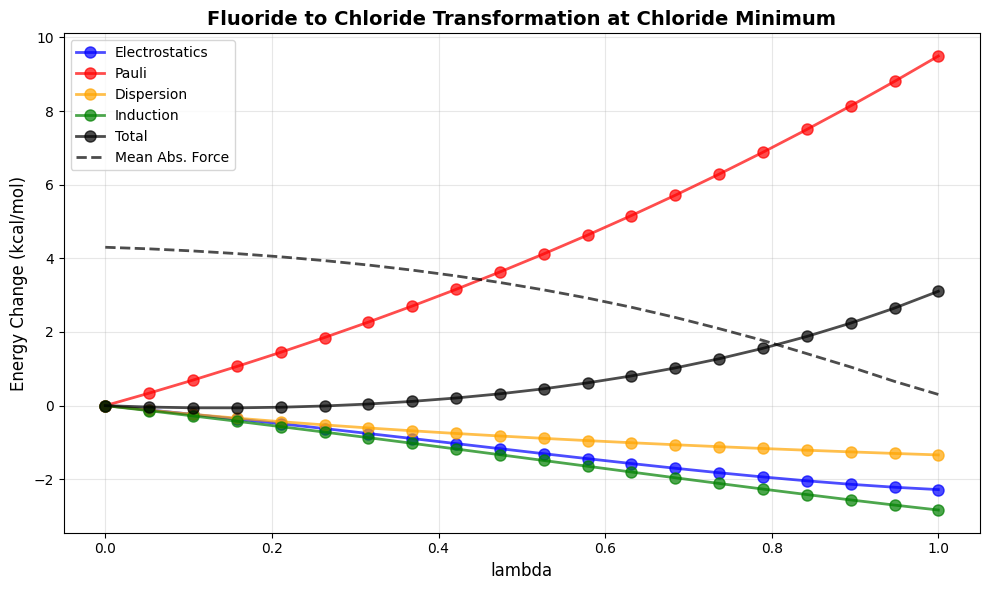

In [14]:
def plot_alchemical_energies():
    elec_energies = []
    disp_energies = []
    pauli_energies = []
    induction_energies = []
    total_energies = []
    mean_abs_force = []
    lam_values = np.linspace(0.0, 1.0, 20)
    for lam in lam_values:
        coords.grad = None # So that grads are not accumulated.
        box.grad = None
        alchemical_system_2.update_parameters(lam)
        energies = alchemical_system_2.system.getEnergy(coords, box)
        energies['total'].backward()
        mean_abs_force.append(np.mean(np.abs(coords.grad.detach().cpu().numpy() * HARTREE2KCAL / BOHR2ANG)))
        
        elec_energies.append(energies['perm_elec'].item() * HARTREE2KCAL)
        disp_energies.append(energies['disp'].item() * HARTREE2KCAL)
        induction_energies.append((energies['pol'] + energies['xpol'] + energies['ct_direct']).item() * HARTREE2KCAL)
        pauli_energies.append(energies['pauli'].item() * HARTREE2KCAL)
        total_energies.append(energies['total'].item() * HARTREE2KCAL)

    elec_energies = np.array(elec_energies)
    disp_energies = np.array(disp_energies)
    pauli_energies = np.array(pauli_energies)
    induction_energies = np.array(induction_energies)
    total_energies = np.array(total_energies)
    mean_abs_force = np.array(mean_abs_force)

    plt.figure(figsize=(10, 6))
    plt.plot(lam_values, elec_energies - elec_energies[0], 'o-', linewidth=2, markersize=8, 
        markerfacecolor='blue', markeredgecolor='blue', color='blue', alpha=0.7, label="Electrostatics")
    plt.plot(lam_values, pauli_energies - pauli_energies[0], 'o-', linewidth=2, markersize=8, 
        markerfacecolor='red', markeredgecolor='red', color='red', alpha=0.7, label="Pauli")
    plt.plot(lam_values, disp_energies - disp_energies[0], 'o-', linewidth=2, markersize=8, 
        markerfacecolor='orange', markeredgecolor='orange', color='orange', alpha=0.7, label="Dispersion")
    plt.plot(lam_values, induction_energies - induction_energies[0], 'o-', linewidth=2, markersize=8, 
        markerfacecolor='green', markeredgecolor='green', color='green', alpha=0.7, label="Induction")
    plt.plot(lam_values, total_energies - total_energies[0], 'o-', linewidth=2, markersize=8, 
            markerfacecolor='black', markeredgecolor='black', color='black', alpha=0.7, label="Total")
    plt.plot(lam_values, mean_abs_force, '--', linewidth=2, markersize=8, 
        markerfacecolor='black', markeredgecolor='black', color='black', alpha=0.7, label="Mean Abs. Force")

    plt.xlabel('lambda', fontsize=12)
    plt.ylabel('Energy Change (kcal/mol)', fontsize=12)
    plt.title('Fluoride to Chloride Transformation at Chloride Minimum', fontsize=14, fontweight='bold')

    plt.grid(True, alpha=0.3)

    plt.legend()

    plt.tight_layout()
    plt.show()

plot_alchemical_energies()